# Songs metadata — exploratory data analysis

This notebook explores `data/songs_metadata.csv`, the metadata table backing the misogyny-dataset-paper
project. Each row is one song, enriched with data pulled from Genius, Last.fm, MusicBrainz, Wikidata and
AcousticBrainz, plus a set of "final" resolved columns (`country`, `gender_or_group`, `genre_main`, ...)
that merge the raw API fields with fallback/inferred values.

The goals of this notebook are to:

1. Load the data and get a first look at it.
2. Audit the quality of a few key columns (`genius_ok`, dates, album).
3. Visualize the genre landscape via Last.fm artist tags.
4. Understand who the artists in the dataset are (person vs. group, gender, country).
5. Verify that the "fill" fallback mechanism actually closes the gaps left by missing API data.
6. Look at genre columns (`genres_all`, `genre_main`) and their provenance (`genre_main_fuente`).
7. Look at the misogyny label distributions (`is_misogynistic` and its subtypes) and the train/test split.
8. Cross-evaluate `genre_main` against `is_misogynistic` to see whether misogyny rates vary by genre.
9. Wrap up with a short written analysis of what the data shows.


## 0. Setup

Standard imports. `ast.literal_eval` is used throughout to parse columns that are stored as stringified Python lists (e.g. `"[['reggaeton', 100], ['rap', 11]]"`).

In [1]:
import ast
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from wordcloud import WordCloud

DATA = Path("../data") if Path("../data").exists() else Path("data")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110


## 1. Read the data with pandas

Load the CSV directly with `pandas.read_csv`. No parsing options are needed at this stage — several
columns look like lists/dates but are stored as plain strings, so we'll parse those individually where
they matter.

In [2]:
df = pd.read_csv(DATA / "songs_metadata.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 2875 rows x 84 columns


,song_id,artist,title,n_verses,lyrics_len,genius_ok,genius_matched_by,genius_id,genius_title,genius_artist,release_date,year,album,featured_artists,producer_artists,writer_artists,pageviews,lastfm_artist_tags,lastfm_track_tags,artist_mbid,mb_artist_name,artist_type,artist_gender,artist_country,artist_area,artist_begin,wikidata_qid,mb_artist_tags,error,wd_ok,wd_qid,wd_gender,wd_citizenship_qids,wd_instance_of,wd_occupation_qids,wd_has_inception,ab_ok,ab_danceability,ab_mood_happy,ab_mood_sad,ab_mood_aggressive,ab_mood_party,ab_mood_relaxed,ab_genre_rosamerica,ab_bpm,ab_key,primary_artist,fill_lastfm_tags,fill_type,fill_gender,fill_country,fill_area,fill_begin,fill_mb_tags,fill_err,deep_year,deep_album,deep_writers,deep_producers,wd_citizenship_labels,wd_occupation_labels,wd_instance_of_labels,release_year,decade,genres_all,genre_main,country,gender_or_group,album_final,country_fuente,genre_main_fuente,gender_or_group_fuente,release_year_fuente,writers,producers,in_train,in_test,is_misogynistic,type_sexualization,type_violence,type_hate,has_gender_stereotype,test_id,test_match_score
0,10002733,Quevedo,LA ÚLTIMA,9,2683,True,id,10002733.0,LA ÚLTIMA,Quevedo,01/02/24,NaN,NaN,[],"['BlueFire', 'GARABATTO', 'Gio Producer', 'KID...",['Quevedo'],47917.0,"[['Reggaeton', 100], ['rap', 11], ['spanish', ...",[],ef9bb29f-f466-4e28-8064-32558f4bb2df,Quevedo,Person,Male,ES,Las Palmas de Gran Canaria,07/12/01,Q112913522,NaN,NaN,True,Q112913522,['male'],['Q29'],['Q5'],"['Q177220', 'Q753110', 'Q2252262']",False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024.0,LA ÚLTIMA,[],[],['España'],"['cantante', 'compositor de canciones', 'rapero']",['ser humano'],2024,2020,"['reggaeton', 'rap', 'hip-hop', 'hip hop', 'da...",reggaeton,España,hombre,LA ÚLTIMA,api,api,api,api,['Quevedo'],"['BlueFire', 'GARABATTO', 'Gio Producer', 'KID...",True,False,NM,NaN,NaN,NaN,NaN,NaN,NaN
1,1001688,Héroes Del Silencio,El Camino Del Exceso,6,1187,True,id,1001688.0,El Camino Del Exceso,Héroes Del Silencio,14/06/93,NaN,El Espíritu del Vino,[],['Phil Manzanera'],"['Bunbury', 'Juan Valdivia', 'Joaquín Cardiel'...",NaN,"[['rock', 100], ['spanish', 56], ['Spanish Roc...",[],4bb712d6-8be9-4c09-810a-eb3bed2be345,Héroes del Silencio,Group,NaN,ES,Spain,1984,Q1434852,NaN,NaN,True,Q1434852,[],[],['Q215380'],[],True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],['grupo musical'],1993,1990,"['rock', 'spanish rock', 'hard rock', 'rock en...",rock,España,grupo,El Espíritu del Vino,api,api,api,api,"['Bunbury', 'Joaquín Cardiel', 'Juan Valdivia'...",['Phil Manzanera'],True,False,NM,NaN,NaN,NaN,NaN,NaN,NaN
2,1002340,Hombres G,Indiana,5,1222,True,id,1002340.0,Indiana,Hombres G,28/04/86,NaN,La Cagaste... Burt Lancaster,[],['Paco Trinidad'],['David Summers'],NaN,"[['spanish', 100], ['rock', 91], ['Rock en Esp...",[],8b1628a7-130a-4faf-96d8-2418bd9043c2,Hombres G,Group,NaN,ES,Spain,1982,Q3772826,NaN,NaN,True,Q3772826,[],[],['Q215380'],[],True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],['grupo musical'],1986,1980,"['rock', 'rock en espanol', 'pop', 'spanish ro...",rock,España,grupo,La Cagaste... Burt Lancaster,api,api,api,api,['David Summers'],['Paco Trinidad'],False,True,M,0.0,1.0,1.0,Y,T_TEST_0057,0.779
3,10048649,"Lucho RK, La Pantera & BDP Music (Producer)",Lucy,7,2789,True,id,10048649.0,Lucy,Lucho RK,15/02/24,NaN,NaN,[],['BDP Music (ESP)'],"['Lucho RK', 'La Pantera']",7791.0,[],[],c3d7f812-47b2-4d78-9ac2-9512817d8add,Lucho RK,Person,Male,ES,Spain,31/03/00,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lucho RK,"[['canarias', 100]]",Person,male,ES,Spain,31/03/00,"[['urban', '1']]",NaN,2024.0,Lucy,[],[],NaN,NaN,NaN,2024,2020,"['canarias', 'urban']",canarias,España,hombre,Lucy,api,api,api,api,"['La Pantera', 'Lucho RK']",['BDP Music (ESP)'],True,False,M,1.0,1.0,1.0,Y,NaN,NaN
4,10055546,Hombres G & Carín León,Te quier

In [3]:
df.info(max_cols=200, show_counts=True)


<class 'pandas.DataFrame'>
RangeIndex: 2875 entries, 0 to 2874
Data columns (total 84 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   song_id                 2875 non-null   int64  
 1   artist                  2875 non-null   str    
 2   title                   2875 non-null   str    
 3   n_verses                2875 non-null   int64  
 4   lyrics_len              2875 non-null   int64  
 5   genius_ok               2875 non-null   bool   
 6   genius_matched_by       2874 non-null   str    
 7   genius_id               2874 non-null   float64
 8   genius_title            2874 non-null   str    
 9   genius_artist           2874 non-null   str    
 10  release_date            1997 non-null   str    
 11  year                    0 non-null      float64
 12  album                   2302 non-null   str    
 13  featured_artists        2874 non-null   str    
 14  producer_artists        2874 non-null   str    
 15

## 2. `genius_ok` — did the Genius lookup succeed?

`genius_ok` records whether the lyrics/metadata lookup against Genius succeeded for that song. We check
its value counts and inspect any row where it is `False`.

In [4]:
genius_counts = df["genius_ok"].value_counts(dropna=False)
print(genius_counts)

n_false = int((df["genius_ok"] == False).sum())
print(f"\nRows with genius_ok == False: {n_false}")


genius_ok
True     2874
False       1
Name: count, dtype: int64

Rows with genius_ok == False: 1


In [5]:
df.loc[df["genius_ok"] == False, ["song_id", "artist", "title", "genius_ok", "error"]]


,song_id,artist,title,genius_ok,error
979,1939644,Andrea Bocelli,Vivo Por Ella (Vivo Per Lei) - Italian - Spani...,False,NaN


**Takeaway:** `genius_ok` is `True` for essentially the whole dataset (2874/2875 rows). Only a single
song — *Andrea Bocelli* — failed the Genius match, and it carries no `error` message, so it looks like an
isolated, harmless matching miss rather than a systemic problem.

## 3. Missing values in `release_date`, `year` and `album`

These three columns come straight from the Genius API response, before any fallback/inference step is
applied (that happens later, in `release_year_fuente` / `album_final`).

In [6]:
cols = ["release_date", "year", "album"]
na_report = pd.DataFrame({
    "n_missing": df[cols].isna().sum(),
    "pct_missing": (df[cols].isna().mean() * 100).round(1),
})
na_report


,n_missing,pct_missing
release_date,878,30.5
year,2875,100.0
album,573,19.9


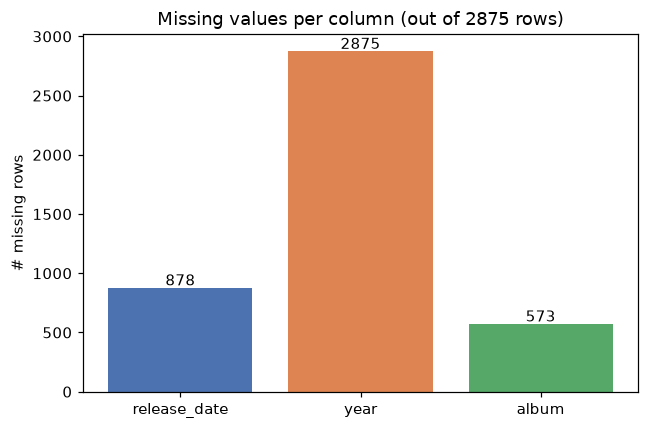

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(na_report.index, na_report["n_missing"], color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("# missing rows")
ax.set_title("Missing values per column (out of {} rows)".format(len(df)))
for i, v in enumerate(na_report["n_missing"]):
    ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.show()


**Takeaway:**

- `year` is missing for **every single row** (2875/2875) — this raw column is effectively unused/dead in
  this export; the dataset relies on `release_year` / `release_year_fuente` instead.
- `release_date` is missing for ~31% of rows (878/2875).
- `album` is missing for ~20% of rows (573/2875) — presumably singles or tracks Genius doesn't associate
  with an album.

## 4. Word cloud of `lastfm_artist_tags`

`lastfm_artist_tags` stores, per artist, a stringified list of `[tag, weight]` pairs returned by the
Last.fm API, e.g. `"[['Reggaeton', 100], ['rap', 11], ...]"`. When Last.fm had no tags for an artist the
field is an empty list `"[]"` — we simply skip those rows rather than treating them as missing data.

In [8]:
def parse_tag_weights(cell):
    """Parse a stringified [[tag, weight], ...] list into a list of (tag, weight) tuples."""
    try:
        parsed = ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        return []
    return [(str(tag).strip().lower(), float(weight)) for tag, weight in parsed]


parsed_tags = df["lastfm_artist_tags"].apply(parse_tag_weights)

n_empty = (parsed_tags.apply(len) == 0).sum()
print(f"Rows with no Last.fm tags (empty list): {n_empty} / {len(df)} ({n_empty / len(df):.1%})")


Rows with no Last.fm tags (empty list): 813 / 2875 (28.3%)


In [9]:
tag_weights = Counter()
for tags in parsed_tags:
    for tag, weight in tags:
        tag_weights[tag] += weight

print(f"Distinct tags: {len(tag_weights)}")
pd.Series(tag_weights).sort_values(ascending=False).head(20)


Distinct tags: 1333


spanish            70718.0
pop                54994.0
latin              47422.0
rock               20523.0
spain              20080.0
reggaeton          16990.0
mexico             16411.0
rap                14832.0
trap               14323.0
hip-hop            12103.0
latin pop           9607.0
argentina           8299.0
flamenco            7908.0
salsa               7836.0
all                 7566.0
rock en espanol     7435.0
hip hop             7385.0
rock argentino      6710.0
mexican             5385.0
ranchera            5357.0
dtype: float64

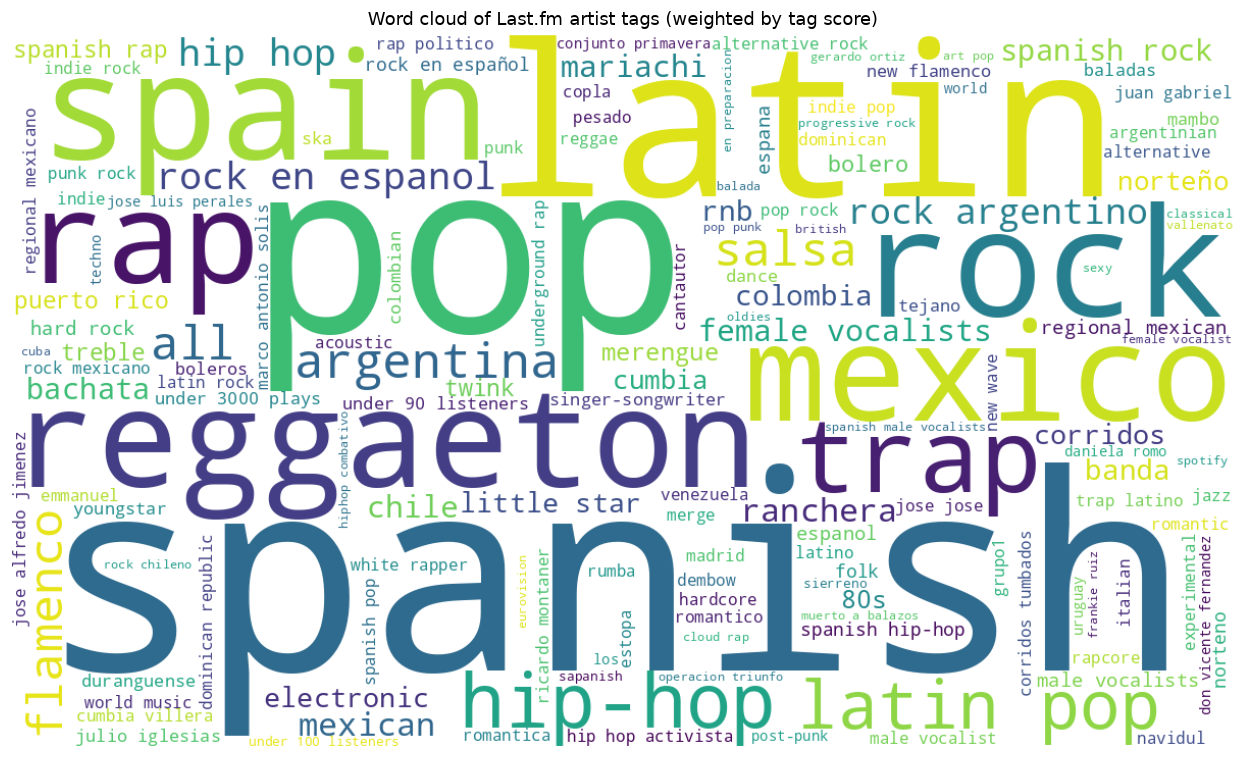

In [10]:
wc = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    colormap="viridis",
    max_words=150,
    prefer_horizontal=0.9,
).generate_from_frequencies(tag_weights)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word cloud of Last.fm artist tags (weighted by tag score)")
plt.tight_layout()
plt.show()


**Takeaway:** genre-ish tags dominate (`reggaeton`, `pop`, `rock`, `trap`, `spanish`, `latin pop`,
`hip hop`, ...), which matches the Spanish/Latin-American pop & urban music focus of the dataset. About
28% of rows have no Last.fm tags at all for their artist, which is worth keeping in mind when using
`lastfm_artist_tags` downstream — it is not evenly available across the dataset.

## 5. Person vs. Group, and demographics of Person artists

`artist_type` (from MusicBrainz) classifies each artist as `Person`, `Group`, `Orchestra`, `Other`,
`Character`, or missing. We first check whether solo artists or groups dominate the dataset, then zoom
into `Person` rows to look at artist type (for context), gender and country.

In [11]:
type_counts = df["artist_type"].value_counts(dropna=False)
print(type_counts)

n_person = int((df["artist_type"] == "Person").sum())
n_group = int((df["artist_type"] == "Group").sum())
more = "Person" if n_person > n_group else "Group"
print(f"\nPerson: {n_person}, Group: {n_group} -> more songs come from a {more.upper()}-type artist")


artist_type
Person       1805
Group         989
NaN            42
Orchestra      36
Other           2
Character       1
Name: count, dtype: int64

Person: 1805, Group: 989 -> more songs come from a PERSON-type artist


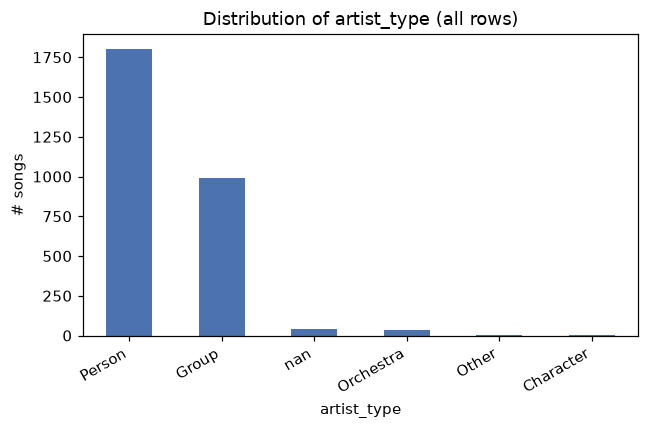

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
type_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("# songs")
ax.set_title("Distribution of artist_type (all rows)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


Person rows: 1805


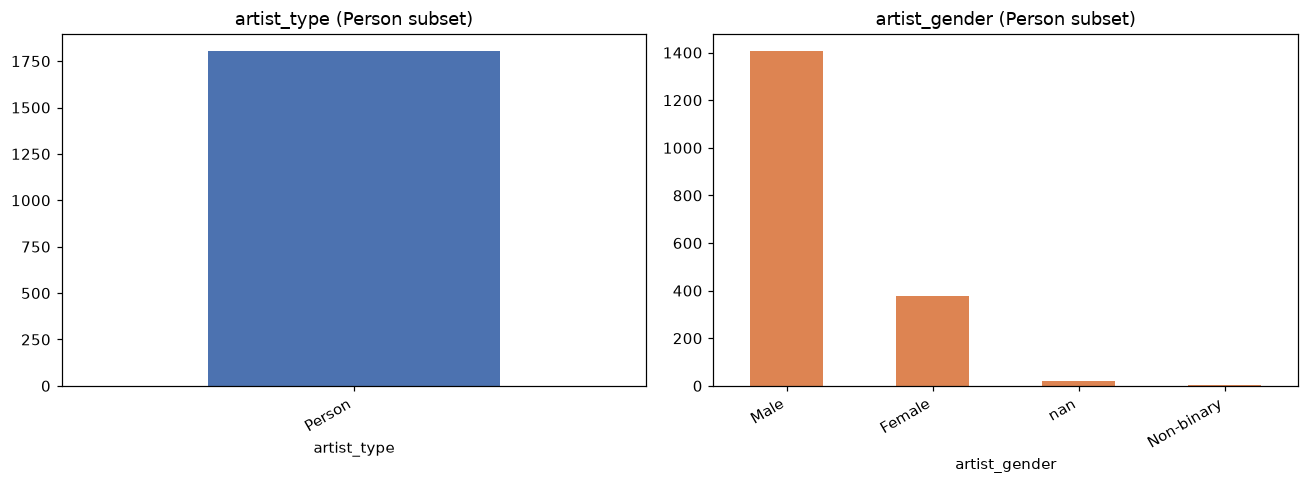

In [13]:
person_df = df[df["artist_type"] == "Person"]
print(f"Person rows: {len(person_df)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

person_df["artist_type"].value_counts(dropna=False).plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("artist_type (Person subset)")

person_df["artist_gender"].value_counts(dropna=False).plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("artist_gender (Person subset)")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()


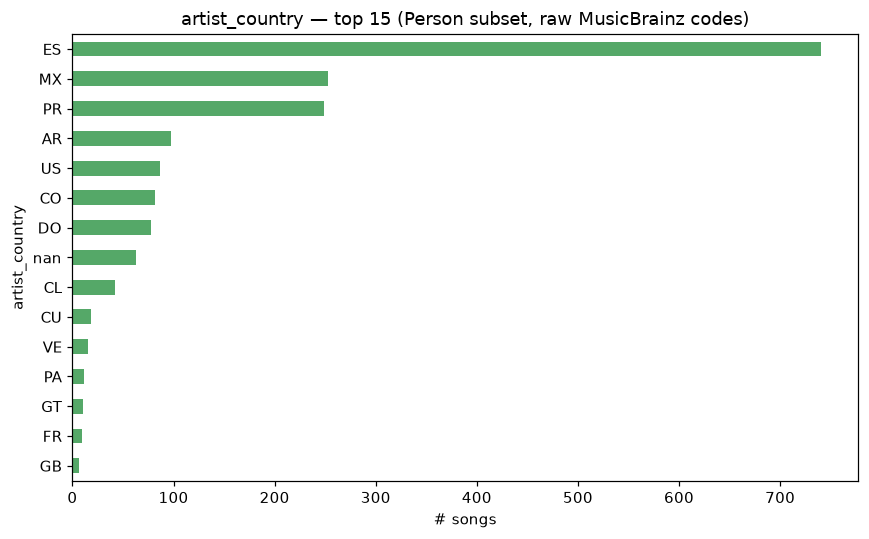

In [14]:
top_countries = person_df["artist_country"].value_counts(dropna=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top_countries.plot(kind="barh", ax=ax, color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("# songs")
ax.set_title("artist_country — top 15 (Person subset, raw MusicBrainz codes)")
plt.tight_layout()
plt.show()


**Takeaway:**

- **Person** artists dominate the dataset (1805 rows) over **Group** artists (989 rows) — roughly 65% of
  songs come from a solo artist.
- Within `Person` rows, `artist_type` is trivially 100% `Person` by construction — it's only shown here
  for completeness alongside the other two distributions.
- `artist_gender` is heavily skewed towards `Male` (1407) over `Female` (376), with only 2 `Non-binary`
  and just 20 missing values (~1.1% of Person rows) — gender is actually well populated once we restrict
  to `Person` rows. The large number of raw `artist_gender` NaNs seen dataset-wide (1087, section 6) comes
  almost entirely from `Group`/`Orchestra` rows, where an individual gender doesn't apply in the first
  place, not from solo artists lacking data.
- `artist_country` is dominated by Spain (`ES`), followed by Mexico, Puerto Rico and Argentina — consistent
  with a Spanish-language song dataset.

## 6. Do the `fill_*` columns actually replace the missing values?

Several raw MusicBrainz-derived columns (`artist_type`, `artist_gender`, `artist_country`, `artist_area`,
`artist_begin`, `mb_artist_tags`) have a matching `fill_*` column (`fill_type`, `fill_gender`, ...) that is
supposed to hold a fallback value fetched separately, to be used when the original is missing.

We check, for each pair, how many original NaNs actually get a non-null fallback in the corresponding
`fill_*` column, and how many are still missing even after the fallback is available.

In [15]:
fill_pairs = [
    ("artist_type", "fill_type"),
    ("artist_gender", "fill_gender"),
    ("artist_country", "fill_country"),
    ("artist_area", "fill_area"),
    ("artist_begin", "fill_begin"),
    ("mb_artist_tags", "fill_mb_tags"),
    ("lastfm_artist_tags", "fill_lastfm_tags"),
]

rows = []
for orig, fill in fill_pairs:
    orig_na = df[orig].isna()
    fill_na = df[fill].isna()
    rows.append({
        "original_col": orig,
        "fill_col": fill,
        "n_missing_original": int(orig_na.sum()),
        "n_filled_by_fallback": int((orig_na & ~fill_na).sum()),
        "n_still_missing_after_fill": int((orig_na & fill_na).sum()),
    })

fill_report = pd.DataFrame(rows)
fill_report["pct_gap_closed"] = (
    (fill_report["n_filled_by_fallback"] / fill_report["n_missing_original"].replace(0, np.nan)) * 100
).round(1)
fill_report


,original_col,fill_col,n_missing_original,n_filled_by_fallback,n_still_missing_after_fill,pct_gap_closed
0,artist_type,fill_type,42,33,9,78.6
1,artist_gender,fill_gender,1087,99,988,9.1
2,artist_country,fill_country,145,70,75,48.3
3,artist_area,fill_area,145,91,54,62.8
4,artist_begin,fill_begin,618,179,439,29.0
5,mb_artist_tags,fill_mb_tags,979,189,790,19.3
6,lastfm_artist_tags,fill_lastfm_tags,0,0,0,NaN


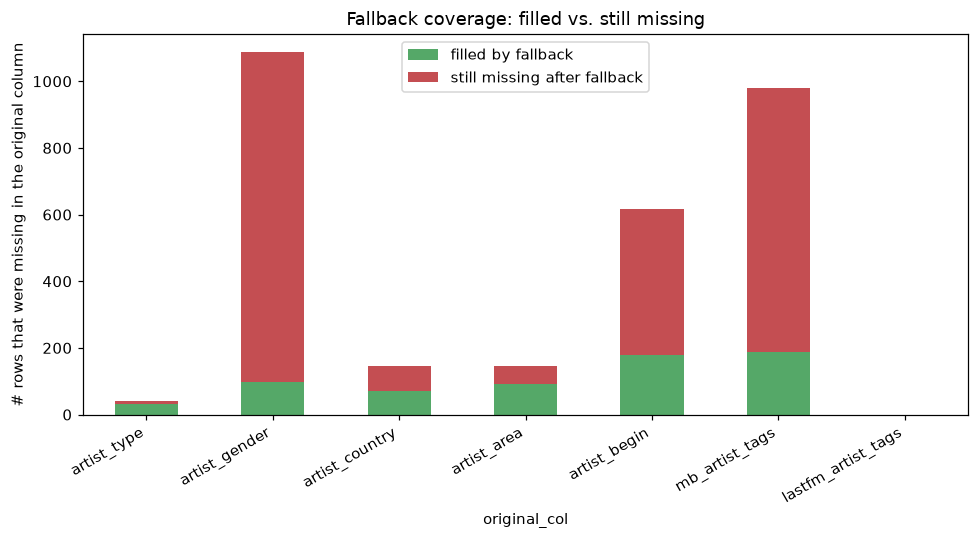

In [16]:
plot_df = fill_report.set_index("original_col")[["n_filled_by_fallback", "n_still_missing_after_fill"]]

fig, ax = plt.subplots(figsize=(9, 5))
plot_df.plot(kind="bar", stacked=True, ax=ax, color=["#55A868", "#C44E52"])
ax.set_ylabel("# rows that were missing in the original column")
ax.set_title("Fallback coverage: filled vs. still missing")
ax.legend(["filled by fallback", "still missing after fallback"])
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Takeaway:** the `fill_*` columns only *partially* replace the missing values — they never reach 100%
coverage on their own. For example `fill_gender` only supplies a value for 99 of the 1087 missing
`artist_gender` rows (~9%), and `fill_begin` covers 179 of 618 (~29%). `fill_lastfm_tags` never applies
because `lastfm_artist_tags` has no true NaNs to begin with (missing tags are encoded as `"[]"` instead).

Despite that, the *final* resolved columns used downstream (`country`, `gender_or_group`, `genre_main`,
`release_year`) have **zero** missing values (checked below) — so the gaps left open by the simple
`fill_*` fallback must be closed by a further step (Wikidata / "deep" search), not by `fill_*` alone.

In [17]:
final_cols = ["country", "gender_or_group", "genre_main", "release_year"]
df[final_cols].isna().sum().rename("n_missing").to_frame()


,n_missing
country,0
gender_or_group,0
genre_main,0
release_year,0


## 7. `genres_all` vs. `genre_main`

- `genres_all` is a stringified list of *all* genre tags resolved for a song's artist.
- `genre_main` is the single dominant genre picked out of that list.

We parse `genres_all`, flatten it to see the overall genre landscape (a song can contribute to several
genres at once), and separately look at the distribution of `genre_main` (one label per song).

In [18]:
def parse_str_list(cell):
    try:
        parsed = ast.literal_eval(cell)
    except (ValueError, SyntaxError):
        return []
    return [str(x) for x in parsed]


genres_all_parsed = df["genres_all"].apply(parse_str_list)
print(f"Rows with an empty genres_all list: {(genres_all_parsed.apply(len) == 0).sum()}")
print(f"Avg. genres per song: {genres_all_parsed.apply(len).mean():.2f}")

genre_all_counts = Counter(g for genres in genres_all_parsed for g in genres)
top_genres_all = pd.Series(genre_all_counts).sort_values(ascending=False).head(20)
top_genres_all


Rows with an empty genres_all list: 0
Avg. genres per song: 7.51


pop                  1243
latin pop             712
reggaeton             598
hip hop               550
rock                  530
rap                   501
trap                  485
hip-hop               385
latin urban           284
trap latino           275
pop rock              264
dance                 217
rock en espanol       209
flamenco              207
rock en español       201
electronic            184
spanish rock          155
salsa                 137
regional mexicano     137
spanish pop           132
dtype: int64

In [19]:
genre_main_value_counts = df["genre_main"].value_counts()
print(f"Distinct main genres: {len(genre_main_value_counts)}")
genre_main_value_counts


Distinct main genres: 262


genre_main
pop                    682
reggaeton              289
trap                   224
rap                    173
rock                   136
                      ... 
edith marquez            1
underground hip-hop      1
detroit                  1
gothic rock              1
drone                    1
Name: count, Length: 262, dtype: int64

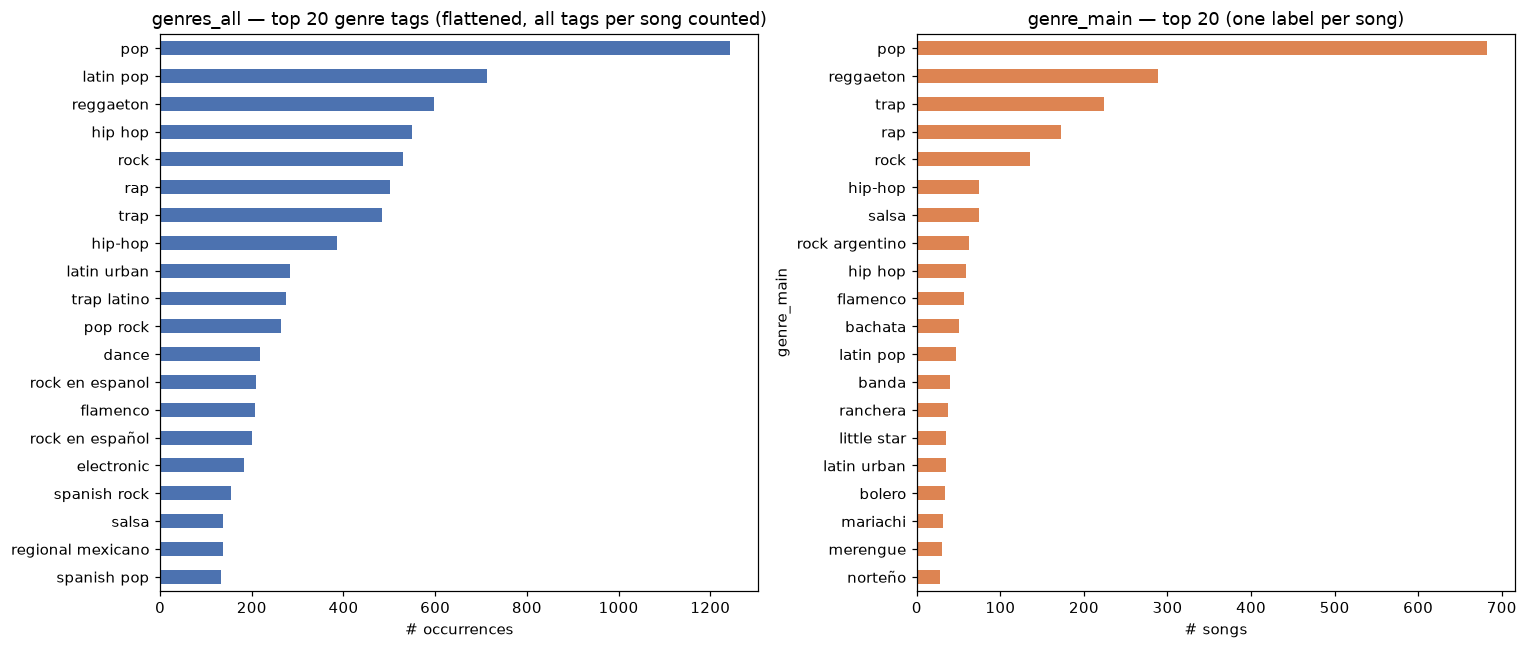

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_genres_all.iloc[::-1].plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("genres_all — top 20 genre tags (flattened, all tags per song counted)")
axes[0].set_xlabel("# occurrences")

top_genre_main = df["genre_main"].value_counts().head(20)
top_genre_main.iloc[::-1].plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("genre_main — top 20 (one label per song)")
axes[1].set_xlabel("# songs")

plt.tight_layout()
plt.show()


### Word cloud of `genre_main`

Same idea as the Last.fm tag cloud in section 4, but built from the single resolved `genre_main` label per
song (one vote per song, no Last.fm popularity weighting), so word size here reflects how many songs in
the dataset fall into each main genre.

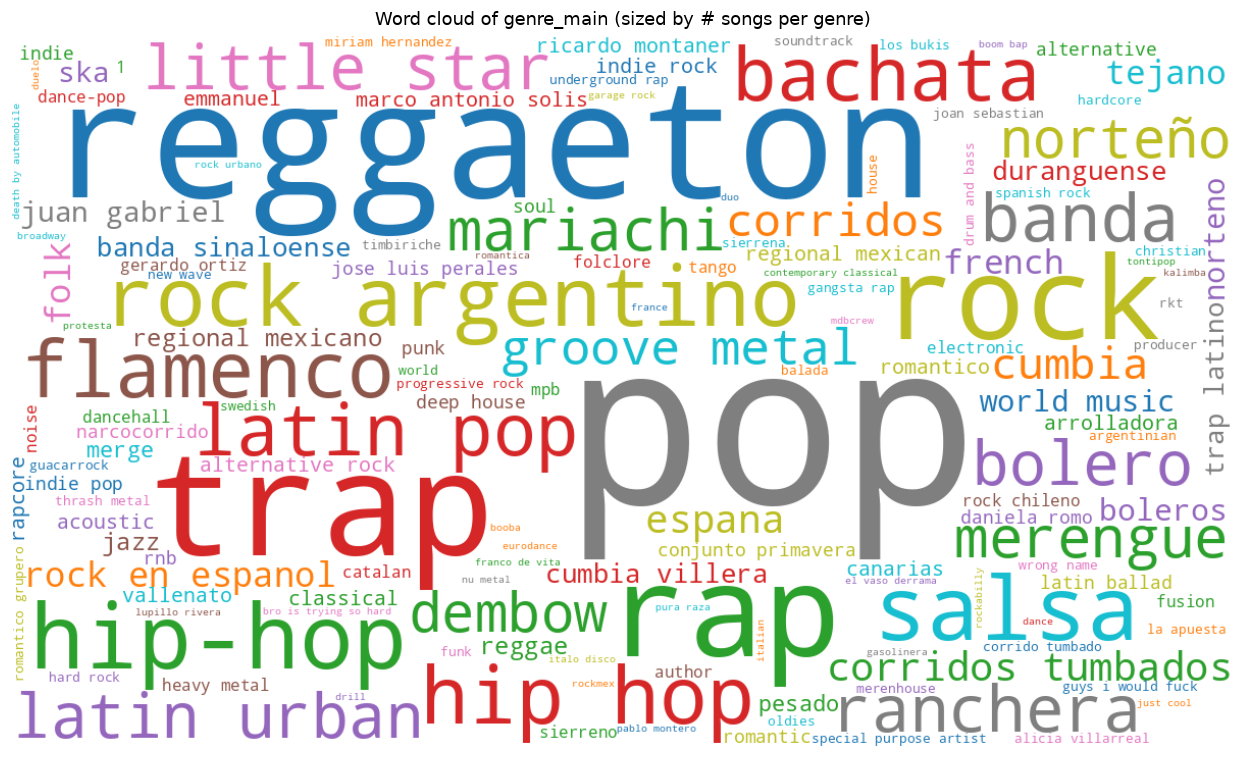

In [21]:
genre_main_counts = df["genre_main"].value_counts()

wc_genre_main = WordCloud(
    width=1200,
    height=700,
    background_color="white",
    colormap="tab10",
    max_words=150,
    prefer_horizontal=0.9,
).generate_from_frequencies(genre_main_counts.to_dict())

plt.figure(figsize=(12, 7))
plt.imshow(wc_genre_main, interpolation="bilinear")
plt.axis("off")
plt.title("Word cloud of genre_main (sized by # songs per genre)")
plt.tight_layout()
plt.show()


**Takeaway:** `genres_all` and `genre_main` tell a consistent story — pop, reggaeton, trap, rap and rock
dominate — but `genres_all` reveals a lot of near-duplicate/overlapping tags (`hip-hop` vs `hip hop`,
`rock en espanol` vs `rock en español` vs `spanish rock`) that `genre_main` collapses away by picking a
single canonical label per song. The `genre_main` word cloud makes that collapse visible: `pop` dominates
outright since it absorbs songs that the raw tag cloud spread across several near-duplicate pop/latin-pop
tags. Neither column has missing values, confirming genre resolution reaches 100% coverage in the final
dataset.

## 8. `genre_main_fuente` — where does `genre_main` come from?

`genre_main_fuente` records the provenance of the resolved `genre_main` value: whether it came directly
from an API response (`api`) or had to be inferred (`inferido`) through a fallback step.

In [22]:
fuente_counts = df["genre_main_fuente"].value_counts(dropna=False)
print(fuente_counts)
print((fuente_counts / len(df) * 100).round(1).astype(str) + "%")


genre_main_fuente
api         2750
inferido     125
Name: count, dtype: int64
genre_main_fuente
api         95.7%
inferido     4.3%
Name: count, dtype: str


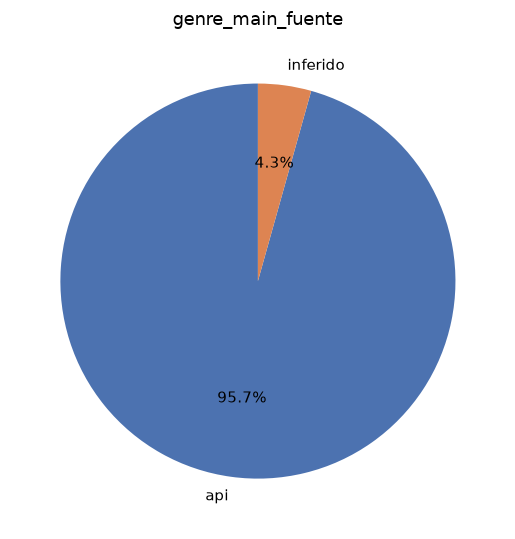

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    fuente_counts.values,
    labels=fuente_counts.index,
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90,
)
ax.set_title("genre_main_fuente")
plt.tight_layout()
plt.show()


In [24]:
df.loc[df["genre_main_fuente"] == "inferido", ["artist", "title", "genres_all", "genre_main", "genre_main_fuente"]].head(10)


,artist,title,genres_all,genre_main,genre_main_fuente
18,Patota,Te Tragas La Gasolina (Daddy Yankee díss),['rap'],rap,inferido
20,"Xinola, Natalie Garcia",Bendita tu Eres (Diosa),['pop'],pop,inferido
21,Sobrepensante,Ego Herido,['trap'],trap,inferido
23,Sobrepensante,El Egoísta,['trap'],trap,inferido
34,Miilooz,"LOS CELOS, EL ODIO Y EL DAÑO",['trap'],trap,inferido
41,DelaJowy & Morad,Bandido,['drill'],drill,inferido
43,tarchi,󠁪corazón partío,['trap'],trap,inferido
50,DAPS (ESP),LiL SHiN CHaN,['trap'],trap,inferido
79,DAPS (ESP) & ​mauvetrip,LiL BaRT,['trap'],trap,inferido
138,Milie,De Hoy En Adelante,['reggaeton'],reggaeton,inferido


**Takeaway:** the vast majority of `genre_main` labels (2750/2875, ~95.7%) come straight from an API
source (Last.fm/MusicBrainz tags), and only ~4.3% (125 rows) needed to be inferred through a fallback
step. Combined with section 7's finding of zero missing `genre_main` values, this shows the genre
resolution pipeline is both largely API-driven and effectively complete.

## 9. Label distributions

The core annotation is `is_misogynistic` (`M` / `NM`), with four finer-grained subtype flags —
`type_sexualization`, `type_violence`, `type_hate` (0/1) and `has_gender_stereotype` (`Y`/`N`) — plus the
`in_train` / `in_test` split flags. We look at all of these before touching genre.

is_misogynistic
NM    1615
M     1260
Name: count, dtype: int64
is_misogynistic
NM    56.2%
M     43.8%
Name: count, dtype: str


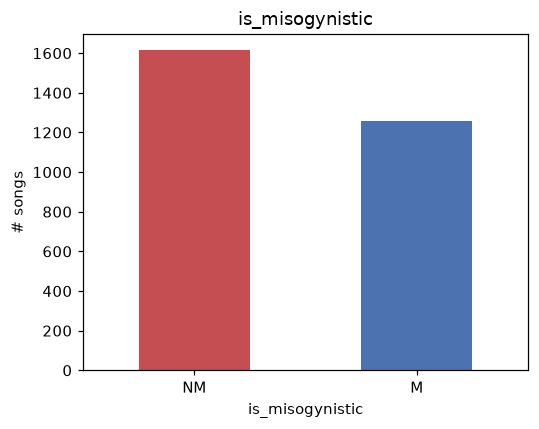

In [25]:
label_counts = df["is_misogynistic"].value_counts(dropna=False)
print(label_counts)
print((label_counts / len(df) * 100).round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(5, 4))
label_counts.plot(kind="bar", ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_ylabel("# songs")
ax.set_title("is_misogynistic")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [26]:
subtype_cols = ["type_sexualization", "type_violence", "type_hate", "has_gender_stereotype"]
print("Missing values (subtype columns are only populated for a subset of rows):")
print(df[subtype_cols].isna().sum())


Missing values (subtype columns are only populated for a subset of rows):
type_sexualization       1294
type_violence            1294
type_hate                1294
has_gender_stereotype    1294
dtype: int64


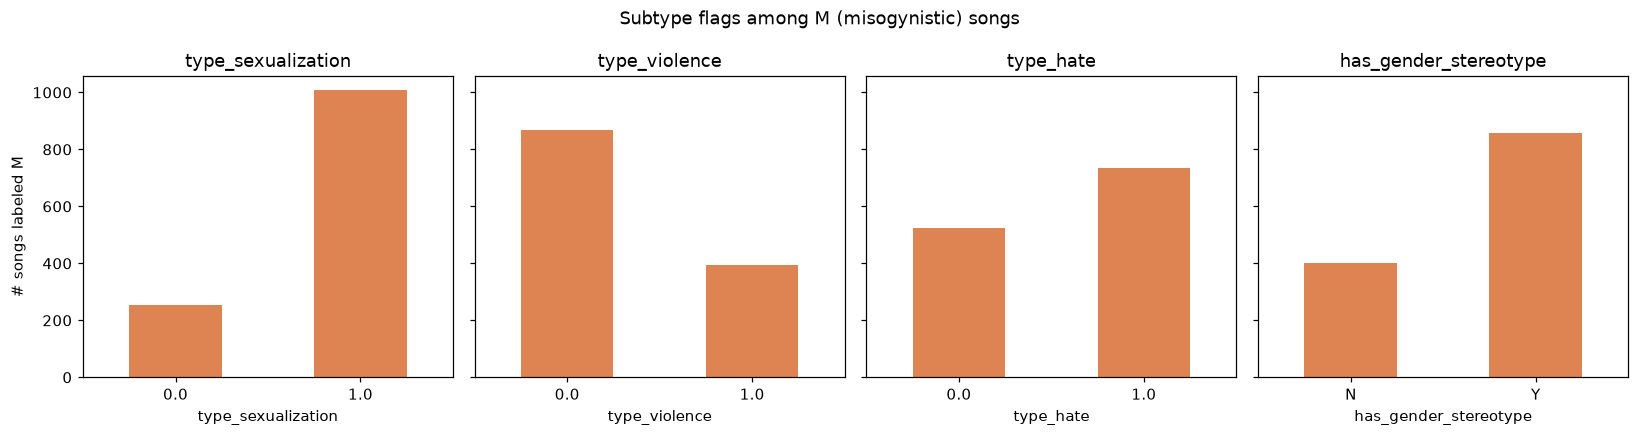

In [27]:
m_df = df[df["is_misogynistic"] == "M"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
for ax, col in zip(axes, subtype_cols):
    m_df[col].value_counts(dropna=False).sort_index().plot(kind="bar", ax=ax, color="#DD8452")
    ax.set_title(col)
axes[0].set_ylabel("# songs labeled M")
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=0)
plt.suptitle("Subtype flags among M (misogynistic) songs")
plt.tight_layout()
plt.show()


In [28]:
# Are subtype columns ever populated for NM songs, and if so, with what values?
nm_with_subtypes = df[(df["is_misogynistic"] == "NM") & df["type_hate"].notna()]
print(f"NM rows with subtype columns populated: {len(nm_with_subtypes)}")
for col in subtype_cols:
    print(f"\n{col}:")
    print(nm_with_subtypes[col].value_counts(dropna=False))


NM rows with subtype columns populated: 321

type_sexualization:
type_sexualization
0.0    321
Name: count, dtype: int64

type_violence:
type_violence
0.0    321
Name: count, dtype: int64

type_hate:
type_hate
0.0    321
Name: count, dtype: int64

has_gender_stereotype:
has_gender_stereotype
N    321
Name: count, dtype: int64


In [29]:
split_counts = df[["in_train", "in_test"]].sum()
print(split_counts)
print()

split_label_ct = pd.crosstab(
    np.where(df["in_test"], "test", "train"),
    df["is_misogynistic"],
)
split_label_ct["total"] = split_label_ct.sum(axis=1)
split_label_ct["pct_M"] = (split_label_ct["M"] / split_label_ct["total"] * 100).round(1)
split_label_ct


in_train    2303
in_test      575
dtype: int64



is_misogynistic,M,NM,total,pct_M
row_0,,,,
test,252,323,575,43.8
train,1008,1292,2300,43.8


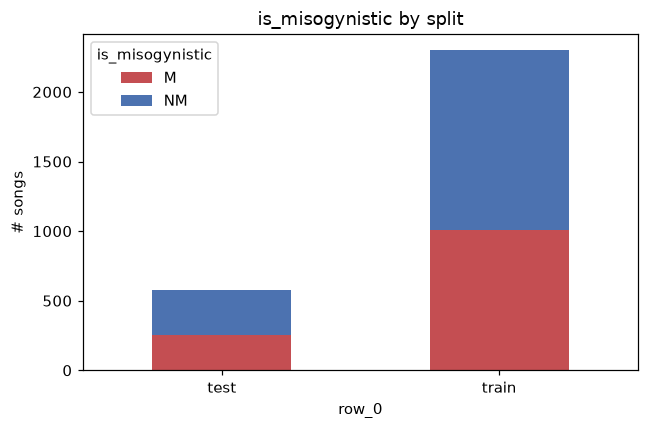

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))
split_label_ct[["M", "NM"]].plot(kind="bar", stacked=True, ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_ylabel("# songs")
ax.set_title("is_misogynistic by split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Takeaway:**

- `is_misogynistic` is fully populated (no NaNs) and reasonably balanced: **1260 M (43.8%)** vs.
  **1615 NM (56.2%)**.
- The subtype columns (`type_sexualization`, `type_violence`, `type_hate`, `has_gender_stereotype`) are
  **not** exclusively for `M` rows: all 1260 `M` rows have them populated, but so do 321 `NM` rows — and in
  every one of those 321 rows all four subtypes are explicitly `0`/`N` rather than missing. Cross-referencing
  with the split shows those 321 rows are exactly the `NM` rows that fall in the **test** set — i.e. the
  test set is exhaustively annotated with subtypes for both classes (so a subtype classifier can be scored
  on true negatives too), while in the training set only `M` rows carry subtype annotations, by
  construction (an `NM` train row has no subtype to record).
- The train/test split is a plain 80/20-ish split (2303 train rows vs. 572 test rows, `in_train`/`in_test`
  are complementary aside from 3 rows flagged as both). The `M` rate is very close between splits (~44%
  train vs. ~44% test — see table above), so the split looks stratified/representative rather than skewed.

## 10. Cross-evaluation: `genre_main` vs. `is_misogynistic`

Does the misogyny rate vary by genre? We restrict to genres with at least 20 songs (to avoid noisy rates
from tiny genres) and compute the share of `M`-labeled songs per genre.

In [31]:
MIN_SONGS = 20
genre_counts = df["genre_main"].value_counts()
frequent_genres = genre_counts[genre_counts >= MIN_SONGS].index

genre_label_df = df[df["genre_main"].isin(frequent_genres)]
genre_label_ct = pd.crosstab(genre_label_df["genre_main"], genre_label_df["is_misogynistic"])
genre_label_ct["total"] = genre_label_ct.sum(axis=1)
genre_label_ct["pct_M"] = (genre_label_ct["M"] / genre_label_ct["total"] * 100).round(1)
genre_label_ct = genre_label_ct.sort_values("pct_M", ascending=False)

overall_pct_m = (df["is_misogynistic"] == "M").mean() * 100
print(f"Overall M rate: {overall_pct_m:.1f}%  |  genres shown have >= {MIN_SONGS} songs each")
genre_label_ct


Overall M rate: 43.8%  |  genres shown have >= 20 songs each


is_misogynistic,M,NM,total,pct_M
genre_main,,,,
latin urban,35,0,35,100.0
dembow,27,1,28,96.4
reggaeton,243,46,289,84.1
groove metal,21,6,27,77.8
trap,159,65,224,71.0
rap,120,53,173,69.4
hip-hop,45,30,75,60.0
merengue,16,14,30,53.3
cumbia,11,10,21,52.4


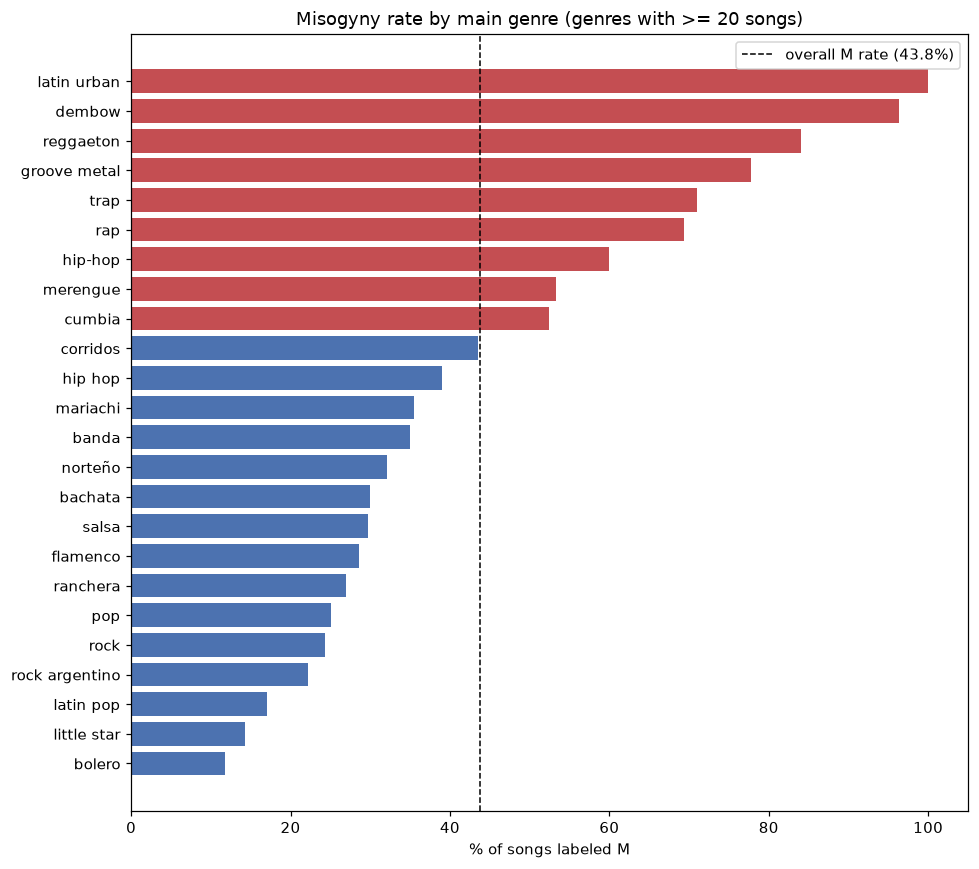

In [32]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#C44E52" if v >= overall_pct_m else "#4C72B0" for v in genre_label_ct["pct_M"]]
ax.barh(genre_label_ct.index, genre_label_ct["pct_M"], color=colors)
ax.invert_yaxis()
ax.axvline(overall_pct_m, color="black", linestyle="--", linewidth=1, label=f"overall M rate ({overall_pct_m:.1f}%)")
ax.set_xlabel("% of songs labeled M")
ax.set_title(f"Misogyny rate by main genre (genres with >= {MIN_SONGS} songs)")
ax.legend()
plt.tight_layout()
plt.show()


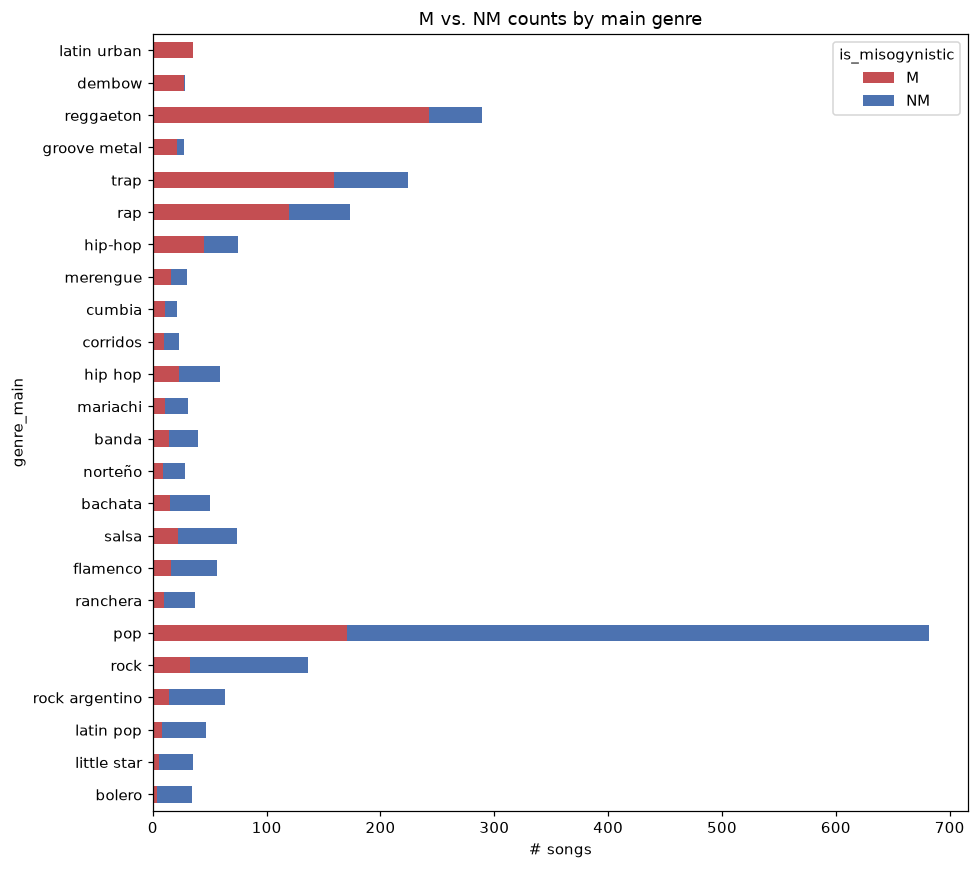

In [33]:
fig, ax = plt.subplots(figsize=(9, 8))
plot_ct = genre_label_ct[["M", "NM"]]
plot_ct.plot(kind="barh", stacked=True, ax=ax, color=["#C44E52", "#4C72B0"])
ax.invert_yaxis()
ax.set_xlabel("# songs")
ax.set_title("M vs. NM counts by main genre")
plt.tight_layout()
plt.show()


**Takeaway:** misogyny rate varies dramatically by genre, far more than random noise would explain:

- **Urban/Latin genres sit at the top:** `latin urban` (100%, n=35), `dembow` (96.4%), `reggaeton` (84.1%,
  n=289), `groove metal` (77.8%), `trap` (71.0%, n=224) and `rap` (69.4%, n=173) are all well above the
  43.8% dataset-wide `M` rate.
- **Traditional/romantic genres sit at the bottom:** `bolero` (11.8%), `little star` (14.3%), `latin pop`
  (17.0%), `rock argentino` (22.2%) and `rock` (24.3%) are well below the overall rate.
- `pop`, the single largest genre (682 songs), sits close to but below the overall rate at 25.1%.
- This is a meaningful confound for any model trained on this dataset: genre and misogyny label are far
  from independent, so a classifier could partly learn "is this reggaeton/trap" as a shortcut for "is this
  misogynistic" rather than picking up on actual lyrical content. Anyone using `genre_main` as a feature
  (or even just knowing the artist's typical genre) should be aware it's a strong, imbalanced prior on the
  label.

## 11. Misogyny rate over time (`release_year` / `decade`)

Does the misogyny rate change across the timespan covered by the dataset? We look at two granularities:

- `decade` — coarse but stable, since the earliest decades (1930s-1970s) only contain a handful of songs.
- `release_year` — finer-grained, restricted to years with at least `MIN_SONGS_YEAR` songs so a single-digit
  sample size doesn't produce a misleadingly extreme percentage.


In [34]:
decade_label_ct = pd.crosstab(df["decade"], df["is_misogynistic"])
decade_label_ct["total"] = decade_label_ct.sum(axis=1)
decade_label_ct["pct_M"] = (decade_label_ct["M"] / decade_label_ct["total"] * 100).round(1)
decade_label_ct = decade_label_ct.sort_index()
decade_label_ct


is_misogynistic,M,NM,total,pct_M
decade,,,,
1930,5,8,13,38.5
1940,3,23,26,11.5
1950,4,24,28,14.3
1960,7,32,39,17.9
1970,15,36,51,29.4
1980,53,126,179,29.6
1990,80,264,344,23.3
2000,141,329,470,30.0
2010,555,457,1012,54.8


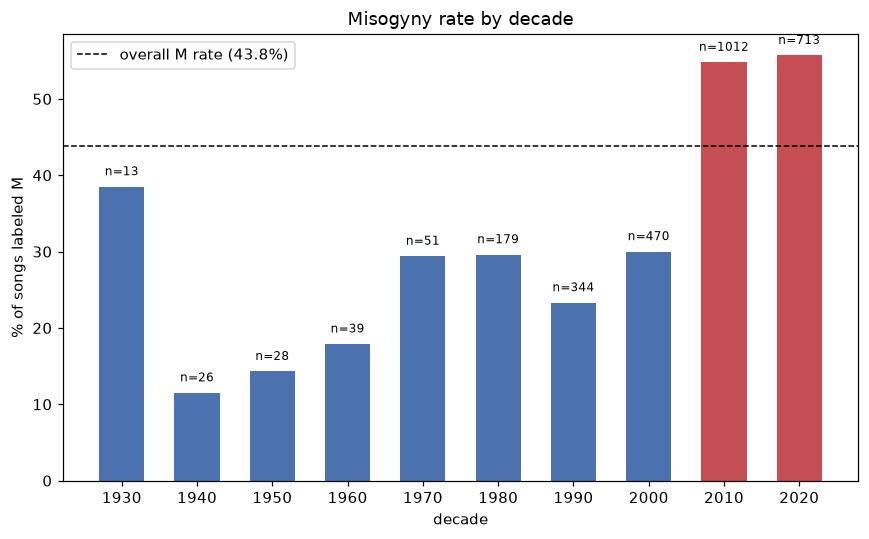

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C44E52" if v >= overall_pct_m else "#4C72B0" for v in decade_label_ct["pct_M"]]
ax.bar(decade_label_ct.index.astype(str), decade_label_ct["pct_M"], color=colors, width=0.6)
ax.axhline(overall_pct_m, color="black", linestyle="--", linewidth=1, label=f"overall M rate ({overall_pct_m:.1f}%)")
for i, (v, n) in enumerate(zip(decade_label_ct["pct_M"], decade_label_ct["total"])):
    ax.text(i, v + 1.5, f"n={n}", ha="center", fontsize=8)
ax.set_ylabel("% of songs labeled M")
ax.set_xlabel("decade")
ax.set_title("Misogyny rate by decade")
ax.legend()
plt.tight_layout()
plt.show()


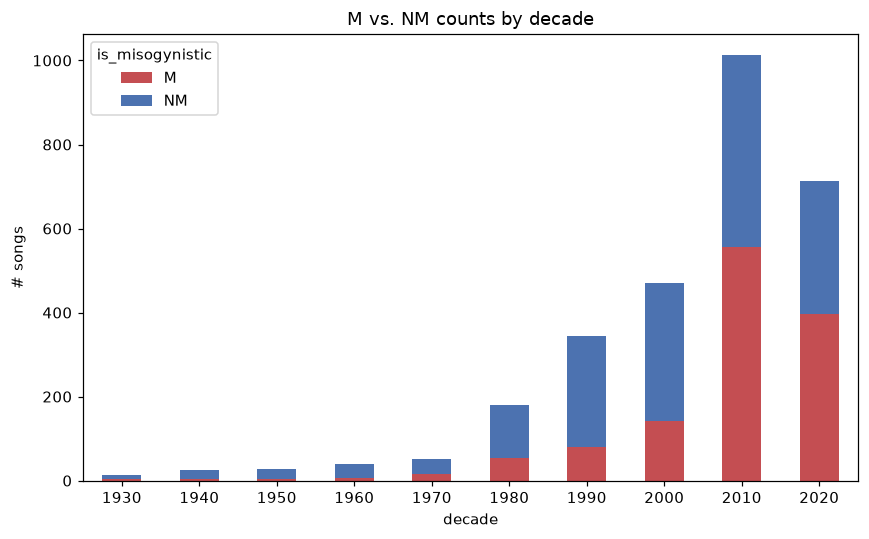

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
decade_label_ct[["M", "NM"]].plot(kind="bar", stacked=True, ax=ax, color=["#C44E52", "#4C72B0"])
ax.set_ylabel("# songs")
ax.set_xlabel("decade")
ax.set_title("M vs. NM counts by decade")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Takeaway:** the misogyny rate is far from constant over time — it roughly doubles between the 20th
century and the 2010s/2020s:

- From the **1940s through the 2000s**, the `M` rate hovers in a fairly narrow band, between **11.5%**
  (1940s) and **30.0%** (2000s), with no clear monotonic trend and some noise from small sample sizes in
  the earliest decades (13-51 songs before 1980).
- Starting in the **2010s**, the rate jumps sharply to **54.8%**, and stays close to that level in the
  **2020s (55.7%)** — both well above the dataset-wide average of 43.8% and roughly double the pre-2010
  decades.
- This lines up with the genre finding from Section 10: `reggaeton`, `trap` and `rap` — the genres with
  the highest `M` rates — are also the genres that came to dominate the Spanish/Latin-American charts from
  the 2010s onward, so the two effects are likely intertwined rather than independent.

### Year-level trend (`release_year`, years with ≥ `MIN_SONGS_YEAR` songs)


In [37]:
MIN_SONGS_YEAR = 20
year_counts = df["release_year"].value_counts()
frequent_years = sorted(year_counts[year_counts >= MIN_SONGS_YEAR].index)

year_label_df = df[df["release_year"].isin(frequent_years)]
year_label_ct = pd.crosstab(year_label_df["release_year"], year_label_df["is_misogynistic"])
year_label_ct["total"] = year_label_ct.sum(axis=1)
year_label_ct["pct_M"] = (year_label_ct["M"] / year_label_ct["total"] * 100).round(1)
year_label_ct = year_label_ct.sort_index()
year_label_ct


is_misogynistic,M,NM,total,pct_M
release_year,,,,
1981,8,13,21,38.1
1982,6,16,22,27.3
1985,8,16,24,33.3
1986,5,18,23,21.7
1988,10,21,31,32.3
1990,3,33,36,8.3
1991,3,19,22,13.6
1992,8,21,29,27.6
1993,5,30,35,14.3


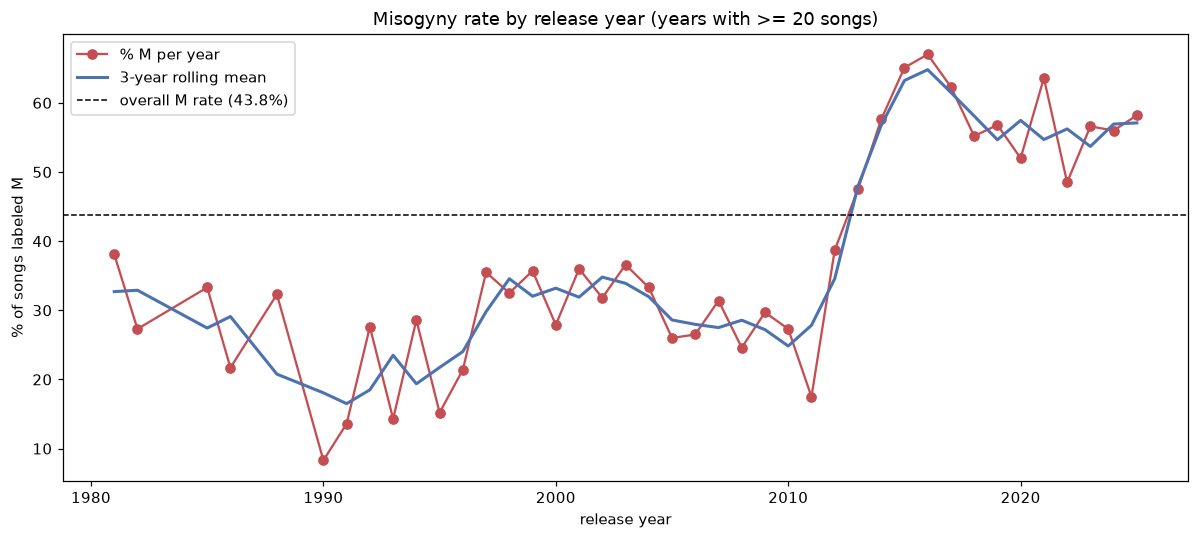

In [38]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(year_label_ct.index, year_label_ct["pct_M"], marker="o", color="#C44E52", label="% M per year")
rolling = year_label_ct["pct_M"].rolling(3, center=True, min_periods=1).mean()
ax.plot(year_label_ct.index, rolling, color="#4C72B0", linewidth=2, label="3-year rolling mean")
ax.axhline(overall_pct_m, color="black", linestyle="--", linewidth=1, label=f"overall M rate ({overall_pct_m:.1f}%)")
ax.set_xlabel("release year")
ax.set_ylabel("% of songs labeled M")
ax.set_title(f"Misogyny rate by release year (years with >= {MIN_SONGS_YEAR} songs)")
ax.legend()
plt.tight_layout()
plt.show()


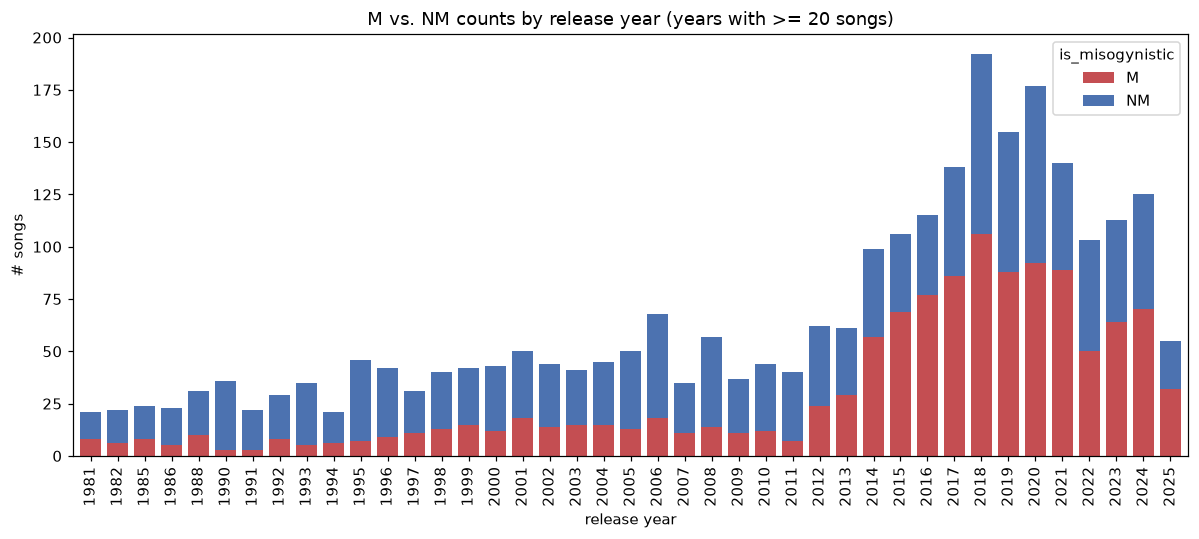

In [39]:
fig, ax = plt.subplots(figsize=(11, 5))
year_label_ct[["M", "NM"]].plot(kind="bar", stacked=True, ax=ax, color=["#C44E52", "#4C72B0"], width=0.8)
ax.set_ylabel("# songs")
ax.set_xlabel("release year")
ax.set_title(f"M vs. NM counts by release year (years with >= {MIN_SONGS_YEAR} songs)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


**Takeaway:** the year-level view (1981-2025, years with ≥ 20 songs) confirms and sharpens the decadal
trend:

- The rate is **low and comparatively stable through the 1980s-2000s**, mostly bouncing between 15% and
  35% (e.g. 8.3% in 1990, 27.9% in 2000), with no clear upward drift.
- A clear **inflection point sits around 2012-2014**: the rate climbs from 38.7% (2012) to 47.5% (2013) to
  57.6% (2014), then peaks at **67.0% in 2016** — the highest of any year in the filtered range.
- From **2014 to 2025** the rate stays consistently high, averaging **56.6%** over the last five years
  (2021-2025) versus **30.5%** over the first five years shown (1981-1985/1990s) — the 3-year rolling mean
  makes this regime shift visible as a step rather than noise around a flat trend.
- The single lowest point, **1990 (8.3%, n=36)**, and the highest, **2016 (67.0%, n=115)**, both have
  large-enough samples that they look like real signal rather than sampling noise.


## 12. The annotation splits: `train.csv` and `test.csv`

The metadata table analysed so far is *derived* from two annotation files that are the actual dataset
deliverable:

- `data/train.csv` — training split, one row per song with `lyrics`, `language` and the misogyny labels.
- `data/test.csv` — held-out test split, same schema.

Neither file carries any of the enrichment columns (genre, country, release year, ...), and the metadata
table carries no lyrics — they are joined on `song_id`. This section loads both splits and answers a
concrete question: **is every song in `train.csv` / `test.csv` actually present in the metadata?**

In [40]:
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")

print(f"train.csv : {train.shape[0]:>5} rows x {train.shape[1]} columns")
print(f"test.csv  : {test.shape[0]:>5} rows x {test.shape[1]} columns")
print(f"metadata  : {df.shape[0]:>5} rows x {df.shape[1]} columns")
print(f"\ntrain + test = {len(train) + len(test)} annotated songs")
print(f"\nSplit columns (identical in both files): {list(train.columns)}")

train.head(3)

train.csv :  2303 rows x 11 columns
test.csv  :   576 rows x 11 columns
metadata  :  2875 rows x 84 columns

train + test = 2879 annotated songs

Split columns (identical in both files): ['song_id', 'song_title', 'artist_id', 'artist_name', 'lyrics', 'language', 'is_misogynistic', 'type_sexualization', 'type_violence', 'type_hate', 'has_gender_stereotype']


,song_id,song_title,artist_id,artist_name,lyrics,language,is_misogynistic,type_sexualization,type_violence,type_hate,has_gender_stereotype
0,4175,Rompe,294,Daddy Yankee,You know\nLos capos están ready\nLas mamis est...,es_LATAM,M,1.0,0.0,0.0,Y
1,87563,Me Estás Tentando,381,Wisin & Yandel,La Mente Maestra\nHace rato que tu mirada me a...,es_LATAM,M,1.0,0.0,0.0,Y
2,90914,Obsesión,548,Aventura (Ft. Judy Santos),"Something flavored, Aventura\nHello?\nShh, sol...",es_LATAM,M,1.0,0.0,0.0,Y


In [41]:
# Basic id hygiene before comparing against the metadata.
for name, split in [("train.csv", train), ("test.csv", test), ("metadata", df)]:
    n_dup = int(split["song_id"].duplicated().sum())
    print(f"{name:<9}: {split['song_id'].nunique():>5} distinct song_id, {n_dup} duplicate row(s)")

train_ids, test_ids, meta_ids = set(train["song_id"]), set(test["song_id"]), set(df["song_id"])
print(f"\nsong_ids appearing in BOTH train.csv and test.csv: {len(train_ids & test_ids)}")

train.csv:  2303 distinct song_id, 0 duplicate row(s)
test.csv :   576 distinct song_id, 0 duplicate row(s)
metadata :  2875 distinct song_id, 0 duplicate row(s)

song_ids appearing in BOTH train.csv and test.csv: 0


### 12.1 Coverage check — is every split song in the metadata?

In [42]:
coverage = pd.DataFrame([
    {
        "split": name,
        "n_songs": len(ids),
        "n_in_metadata": len(ids & meta_ids),
        "n_missing_from_metadata": len(ids - meta_ids),
        "pct_covered": round(len(ids & meta_ids) / len(ids) * 100, 2),
    }
    for name, ids in [("train.csv", train_ids), ("test.csv", test_ids)]
])
coverage.loc[len(coverage)] = {
    "split": "train + test",
    "n_songs": len(train_ids | test_ids),
    "n_in_metadata": len((train_ids | test_ids) & meta_ids),
    "n_missing_from_metadata": len((train_ids | test_ids) - meta_ids),
    "pct_covered": round(len((train_ids | test_ids) & meta_ids) / len(train_ids | test_ids) * 100, 2),
}

print(f"Metadata rows not belonging to either split: {len(meta_ids - (train_ids | test_ids))}")
coverage

Metadata rows not belonging to either split: 0


,split,n_songs,n_in_metadata,n_missing_from_metadata,pct_covered
0,train.csv,2303,2303,0,100.00
1,test.csv,576,572,4,99.31
2,train + test,2879,2875,4,99.86


In [43]:
# The songs that are annotated but have NO metadata row.
missing_ids = sorted((train_ids | test_ids) - meta_ids)
print(f"{len(missing_ids)} annotated song(s) missing from the metadata: {missing_ids}")

missing_rows = pd.concat([
    train[train["song_id"].isin(missing_ids)].assign(split="train"),
    test[test["song_id"].isin(missing_ids)].assign(split="test"),
])
missing_rows[["split", "song_id", "song_title", "artist_name", "language", "is_misogynistic"]]

4 annotated song(s) missing from the metadata: [918413, 1175681, 1200201, 1762369]


,split,song_id,song_title,artist_name,language,is_misogynistic
44,test,918413,Lo Siento Mi Amor,Lupita D'Alessio,es_LATAM,NM
84,test,1175681,Mi Tenampa,Pedro Infante,es_LATAM,NM
87,test,1200201,"Donde Estés, Con Quien Estés",Camilo Sesto,es_LATAM,NM
197,test,1762369,Lo Mejor De Tu Vida,Bertin Osborne,es_ES,M


### 12.2 Do the `in_train` / `in_test` flags match real membership?

The metadata carries its own `in_train` / `in_test` boolean flags (used back in section 9). Now that the
source splits are loaded we can check them against the truth instead of trusting them.

In [44]:
really_train = df["song_id"].isin(train_ids)
really_test = df["song_id"].isin(test_ids)

print("in_train flag vs. real membership in train.csv:")
print(pd.crosstab(df["in_train"], really_train, rownames=["in_train flag"], colnames=["in train.csv"]))
print("\nin_test flag vs. real membership in test.csv:")
print(pd.crosstab(df["in_test"], really_test, rownames=["in_test flag"], colnames=["in test.csv"]))
print(f"\nMetadata rows flagged as BOTH in_train and in_test: {int((df['in_train'] & df['in_test']).sum())}")
print(f"Metadata rows flagged as NEITHER:                   {int((~df['in_train'] & ~df['in_test']).sum())}")

in_train flag vs. real membership in train.csv:
in train.csv   False  True 
in_train flag              
False            572      0
True               0   2303

in_test flag vs. real membership in test.csv:
in test.csv   False  True 
in_test flag              
False          2300      0
True              3    572

Metadata rows flagged as BOTH in_train and in_test: 3
Metadata rows flagged as NEITHER:                   0


In [45]:
# Why the mismatch? The metadata was linked to test.csv by FUZZY TITLE MATCHING
# (`test_id` / `test_match_score`), not by song_id -- `test_id` is the 1-based row number of test.csv.
test_rows = test.reset_index().rename(columns={"index": "test_row"})

linked = df.dropna(subset=["test_id"]).copy()
linked["test_row"] = linked["test_id"].str.extract(r"(\d+)")[0].astype(int) - 1  # T_TEST_0045 -> row 44
linked = linked.merge(
    test_rows[["test_row", "song_id", "song_title", "artist_name"]],
    on="test_row",
    suffixes=("_meta", "_testcsv"),
)

print(f"Fuzzy-linked metadata rows: {len(linked)}  |  match score min={linked['test_match_score'].min():.3f}, "
      f"median={linked['test_match_score'].median():.3f}")

bad_links = linked[linked["song_id_meta"] != linked["song_id_testcsv"]]
print(f"Links that point at a DIFFERENT song than the song_id says: {len(bad_links)}")
bad_links[["test_id", "test_match_score", "song_id_meta", "artist", "title",
           "song_id_testcsv", "artist_name", "song_title", "in_train", "in_test"]]

Fuzzy-linked metadata rows: 575  |  match score min=0.723, median=0.909
Links that point at a DIFFERENT song than the song_id says: 3


,test_id,test_match_score,song_id_meta,artist,title,song_id_testcsv,artist_name,song_title,in_train,in_test
16,T_TEST_0045,1.000,1056780,Rocío Jurado,Lo siento mi amor,918413,Lupita D'Alessio,Lo Siento Mi Amor,True,True
91,T_TEST_0198,0.891,1303510,Julio Iglesias,Lo Mejor de Tu Vida,1762369,Bertin Osborne,Lo Mejor De Tu Vida,True,True
246,T_TEST_0085,1.000,2081217,Ram herrera,Entre cantina y cantina,1175681,Pedro Infante,Mi Tenampa,True,True


### 12.3 Do the labels agree between the splits and the metadata?

For every song that *is* in both places, the label columns should be identical — they are the same
annotation, copied. We compare all five label columns on the joined rows.

In [46]:
LABEL_COLS = ["is_misogynistic", "type_sexualization", "type_violence", "type_hate", "has_gender_stereotype"]

rows = []
for name, split in [("train", train), ("test", test)]:
    joined = split.merge(df[["song_id"] + LABEL_COLS], on="song_id", suffixes=("_split", "_meta"))
    for col in LABEL_COLS:
        a, b = joined[col + "_split"], joined[col + "_meta"]
        both_na = a.isna() & b.isna()
        rows.append({
            "split": name,
            "column": col,
            "n_compared": len(joined),
            "n_equal": int((both_na | (a.astype(str) == b.astype(str))).sum()),
            "n_conflicting_values": int((a.notna() & b.notna() & (a.astype(str) != b.astype(str))).sum()),
            "n_missing_in_split_only": int((a.isna() & b.notna()).sum()),
            "n_missing_in_metadata_only": int((b.isna() & a.notna()).sum()),
        })

label_audit = pd.DataFrame(rows)
label_audit

,split,column,n_compared,n_equal,n_conflicting_values,n_missing_in_split_only,n_missing_in_metadata_only
0,train,is_misogynistic,2303,2303,0,0,0
1,train,type_sexualization,2303,2303,0,0,0
2,train,type_violence,2303,2303,0,0,0
3,train,type_hate,2303,2303,0,0,0
4,train,has_gender_stereotype,2303,2303,0,0,0
5,test,is_misogynistic,572,572,0,0,0
6,test,type_sexualization,572,251,0,321,0
7,test,type_violence,572,251,0,321,0
8,test,type_hate,572,251,0,321,0
9,test,has_gender_stereotype,572,251,0,321,0


**Takeaway — the coverage question, answered:**

- **`train.csv` is fully covered: all 2303 songs have a metadata row (100%).**
- **`test.csv` is *not*: 572 of its 576 songs have a metadata row (99.3%); 4 are missing entirely** —
  song_ids `918413` (*Lupita D'Alessio — Lo Siento Mi Amor*), `1175681` (*Pedro Infante — Mi Tenampa*),
  `1200201` (*Camilo Sesto — Donde Estés, Con Quien Estés*) and `1762369`
  (*Bertin Osborne — Lo Mejor De Tu Vida*). All four are `es_LATAM`/`es_ES` songs by older artists.
- The metadata's 2875 rows are therefore exactly `2303 train + 572 test` — there are **no** metadata rows
  that don't belong to a split, and no song appears in both splits.
- **The `in_train` / `in_test` flags are not fully trustworthy.** `in_train` is exact, but `in_test` is
  `True` for 575 rows while only 572 test songs are actually present: the metadata was linked to
  `test.csv` by *fuzzy title matching* (`test_id` / `test_match_score`), not by `song_id`. Three links
  landed on a same-titled song by a different artist — e.g. *Rocío Jurado — Lo siento mi amor* (a **train**
  song) was matched with score 1.000 to test row 45, which is *Lupita D'Alessio — Lo Siento Mi Amor*. Those
  3 rows are flagged `in_train` **and** `in_test` simultaneously, and they are exactly why 3 of the 4
  missing test songs look "covered" when you count flags instead of ids. **Prefer joining on `song_id`
  over reading `in_test`.**
- **Labels are consistent** wherever both sources have them: `is_misogynistic` matches on 100% of the
  2875 joined rows, and so do the four subtype columns in train. The only discrepancy is in test, where
  321 `NM` rows have **empty** subtype fields in `test.csv` but explicit `0`/`N` values in the metadata —
  i.e. the "exhaustively annotated test set" noted in section 9 is an artefact of the metadata build
  filling `NM` subtypes with zeros, not something the source annotation file contains.

## 13. Attaching the metadata to the splits

Finally, we build the two joined tables that downstream modelling actually wants: the annotation splits
(`song_id`, `lyrics`, `language`, labels) **plus** the resolved metadata columns (`release_year`,
`decade`, `country`, `gender_or_group`, `genre_main`, ...), joined on `song_id`.

The label columns are deliberately taken from the splits (they are the source of truth, and unlike the
metadata they leave `NM` subtypes empty rather than imputing zeros), so only non-label metadata columns
are attached.

In [47]:
META_COLS = [
    "artist", "title", "n_verses", "lyrics_len",
    "release_date", "release_year", "decade", "album_final",
    "country", "gender_or_group", "genres_all", "genre_main", "genre_main_fuente",
]

train_meta = train.merge(df[["song_id"] + META_COLS], on="song_id", how="left", validate="one_to_one")
test_meta = test.merge(df[["song_id"] + META_COLS], on="song_id", how="left", validate="one_to_one")

print(f"train_meta: {train_meta.shape[0]} rows x {train_meta.shape[1]} columns")
print(f"test_meta : {test_meta.shape[0]} rows x {test_meta.shape[1]} columns")
print(f"\nRows with no metadata attached -> train: {train_meta['genre_main'].isna().sum()}, "
      f"test: {test_meta['genre_main'].isna().sum()}")

train_meta.drop(columns=["lyrics"]).head(3)

train_meta: 2303 rows x 24 columns
test_meta : 576 rows x 24 columns

Rows with no metadata attached -> train: 0, test: 4


,song_id,song_title,artist_id,artist_name,language,is_misogynistic,type_sexualization,type_violence,type_hate,has_gender_stereotype,artist,title,n_verses,lyrics_len,release_date,release_year,decade,album_final,country,gender_or_group,genres_all,genre_main,genre_main_fuente
0,4175,Rompe,294,Daddy Yankee,es_LATAM,M,1.0,0.0,0.0,Y,Daddy Yankee,Rompe,8,2223,30/09/05,2005,2000,Barrio Fino En Directo,Puerto Rico,hombre,"['reggaeton', 'hip-hop', 'rap', 'daddy yankee'...",reggaeton,api
1,87563,Me Estás Tentando,381,Wisin & Yandel,es_LATAM,M,1.0,0.0,0.0,Y,Wisin & Yandel,Me Estás Tentando,9,2715,20/10/08,2008,2000,La Revolución (Deluxe),Puerto Rico,grupo,"['reggaeton', 'dance', 'wisin y yandel', 'hip-...",reggaeton,api
2,90914,Obsesión,548,Aventura (Ft. Judy Santos),es_LATAM,M,1.0,0.0,0.0,Y,Aventura (Ft. Judy Santos),Obsesión,7,2589,02/07/02,2002,2000,We Broke the Rules,Estados Unidos,grupo,"['bachata', 'wisin y yandel']",bachata,api


In [48]:
# Per-column coverage of the attached metadata (NaN here = either the song is one of the 4 missing ones,
# or the metadata itself had no value for that column).
attach_coverage = pd.DataFrame({
    "train_pct_filled": (train_meta[META_COLS].notna().mean() * 100).round(1),
    "test_pct_filled": (test_meta[META_COLS].notna().mean() * 100).round(1),
    "train_n_missing": train_meta[META_COLS].isna().sum(),
    "test_n_missing": test_meta[META_COLS].isna().sum(),
})
attach_coverage

,train_pct_filled,test_pct_filled,train_n_missing,test_n_missing
artist,100.0,99.3,0,4
title,100.0,99.3,0,4
n_verses,100.0,99.3,0,4
lyrics_len,100.0,99.3,0,4
release_date,69.8,67.5,695,187
release_year,100.0,99.3,0,4
decade,100.0,99.3,0,4
album_final,100.0,99.3,0,4
country,100.0,99.3,0,4
gender_or_group,100.0,99.3,0,4


In [49]:
# Is the test split representative of train on the metadata dimensions?
def split_profile(name, split_df):
    n = len(split_df)
    return {
        "split": name,
        "n_songs": n,
        "pct_M": round((split_df["is_misogynistic"] == "M").mean() * 100, 1),
        "pct_es_ES": round((split_df["language"] == "es_ES").mean() * 100, 1),
        "median_release_year": split_df["release_year"].median(),
        "pct_reggaeton_trap_rap": round(split_df["genre_main"].isin(["reggaeton", "trap", "rap"]).mean() * 100, 1),
        "pct_group_artist": round((split_df["gender_or_group"] == "grupo").mean() * 100, 1),
        "median_lyrics_len": split_df["lyrics_len"].median(),
    }

pd.DataFrame([split_profile("train", train_meta), split_profile("test", test_meta)]).set_index("split")

,n_songs,pct_M,pct_es_ES,median_release_year,pct_reggaeton_trap_rap,pct_group_artist,median_lyrics_len
split,,,,,,,
train,2303,43.8,48.7,2014.0,24.0,35.9,1619.0
test,576,43.8,48.6,2014.0,23.1,36.6,1549.0


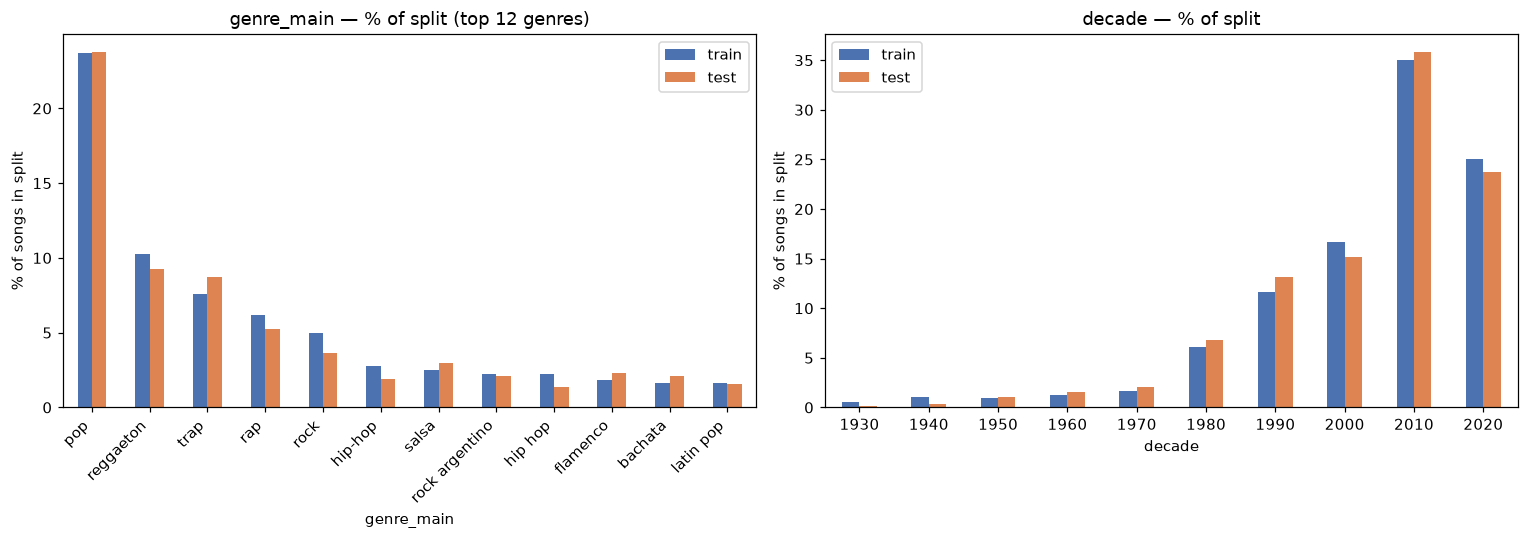

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_genres = df["genre_main"].value_counts().head(12).index
genre_share = pd.DataFrame({
    "train": train_meta["genre_main"].value_counts(normalize=True).reindex(top_genres) * 100,
    "test": test_meta["genre_main"].value_counts(normalize=True).reindex(top_genres) * 100,
})
genre_share.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("genre_main — % of split (top 12 genres)")
axes[0].set_ylabel("% of songs in split")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

decade_share = pd.DataFrame({
    "train": train_meta["decade"].value_counts(normalize=True).sort_index() * 100,
    "test": test_meta["decade"].value_counts(normalize=True).sort_index() * 100,
})
decade_share.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("decade — % of split")
axes[1].set_ylabel("% of songs in split")
plt.setp(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [51]:
# Persist the enriched splits so modelling code can read lyrics + metadata from a single file.
train_meta.to_csv(DATA / "train_with_metadata.csv", index=False)
test_meta.to_csv(DATA / "test_with_metadata.csv", index=False)

print(f"Wrote {DATA / 'train_with_metadata.csv'} and {DATA / 'test_with_metadata.csv'}")
test_meta.drop(columns=["lyrics"]).head(3)

Wrote ../data/train_with_metadata.csv and ../data/test_with_metadata.csv


,song_id,song_title,artist_id,artist_name,language,is_misogynistic,type_sexualization,type_violence,type_hate,has_gender_stereotype,artist,title,n_verses,lyrics_len,release_date,release_year,decade,album_final,country,gender_or_group,genres_all,genre_main,genre_main_fuente
0,172773,Alergia,58,Violadores del Verso,es_ES,NM,NaN,NaN,NaN,NaN,Violadores del Verso,Alergia,10.0,3440.0,02/11/06,2006.0,2000.0,Vivir Para Contarlo,España,grupo,"['hip-hop', 'rap', 'spanish hip-hop', 'hip hop...",hip-hop,api
1,172778,No Somos Ciegos,58,Violadores del Verso,es_ES,NM,NaN,NaN,NaN,NaN,Violadores del Verso,No Somos Ciegos,6.0,4510.0,02/11/06,2006.0,2000.0,Vivir Para Contarlo,España,grupo,"['hip-hop', 'rap', 'spanish hip-hop', 'hip hop...",hip-hop,api
2,174267,"Marrones, Morenas, Coronas",58,Violadores del Verso,es_ES,M,1.0,0.0,0.0,N,Violadores del Verso,"Marrones, Morenas, Coronas",8.0,3810.0,11/01/01,2001.0,2000.0,Vicios y Virtudes,España,grupo,"['hip-hop', 'rap', 'spanish hip-hop', 'hip hop...",hip-hop,api


**Takeaway:** joining on `song_id` attaches the full metadata to 100% of `train.csv` and 99.3% of
`test.csv` (the 4 unmatched test songs carry `NaN` metadata and are easy to filter out or re-scrape).
Every attached column is 100% populated on the matched rows except `release_date`, which is ~31% empty in
both splits — the same raw-Genius gap seen in section 3, and the reason to use the resolved `release_year`
instead. The two splits profile almost identically on every metadata dimension — M rate 43.8% in both,
`es_ES` share 48.7% vs. 48.6%, median release year 2014 in both, reggaeton/trap/rap share 24.0% vs. 23.1%,
group-artist share 35.9% vs. 36.6% — and their genre and decade distributions overlap closely, so the test
split is representative of train on every attribute enriched here.

## 14. Overall data analysis

Putting the sections above together:

- **Data quality is generally strong, once the resolution pipeline runs.** Raw API fields (`artist_gender`,
  `mb_artist_tags`, `release_date`, `album`, and especially `year`, which is 100% empty) are riddled with
  gaps straight out of Genius/MusicBrainz/Last.fm. But the dataset's "final" columns
  (`country`, `gender_or_group`, `genre_main`, `release_year`, `album_final`) reach **0% missing values**,
  meaning a multi-stage enrichment pipeline (raw API → `fill_*` fallback → Wikidata/"deep" inference) is
  doing real, effective work to close those gaps — the `fill_*` columns alone only close a modest fraction
  of the gap (9–48% depending on the field), so most of the resolution happens further downstream
  (`*_fuente == "inferido"`).
- **Genre coverage is essentially complete and API-driven.** `genres_all`/`genre_main` have no missing
  values, and ~96% of `genre_main` labels are sourced directly from an API rather than inferred, so the
  genre labels can be trusted as largely primary-source data. The Last.fm tag word cloud confirms the
  dataset leans heavily on reggaeton, pop, trap, rap and rock — a genre mix consistent with contemporary
  Spanish and Latin American popular music.
- **The artist population is mostly solo, mostly male, and mostly Spanish-speaking.** Solo (`Person`)
  artists outnumber groups roughly 2:1. Among solo artists, `artist_gender` is well populated (only ~1.1%
  missing) and heavily skewed male (1407 male vs. 376 female vs. 2 non-binary) — the large amount of raw
  `artist_gender` missingness seen at the whole-dataset level is mostly an artifact of `Group`/`Orchestra`
  rows, where the field doesn't apply, not a Person-level data gap. Geographically, Spain, Mexico, Puerto
  Rico and Argentina supply the bulk of solo artists, matching the Spanish/Latin-American scope implied by
  the genre analysis.
- **`genius_ok` is a non-issue.** Genius matching succeeded for 2874/2875 songs; the single failure looks
  like an isolated miss rather than a systemic data-collection problem.
- **The label set is complete and reasonably balanced, but genre is a strong confound.**
  `is_misogynistic` has no missing values and a 43.8% M / 56.2% NM split that holds steady across the
  train/test partition, so the split looks stratified. However, the `M` rate ranges from ~12% (`bolero`) to
  100% (`latin urban`) depending on `genre_main`, with urban/Latin genres (reggaeton, trap, rap, dembow)
  far above average and romantic/traditional genres (bolero, latin pop, rock) far below it. Any model or
  metric built on this dataset should treat genre as a confound to control for, not just a feature to
  ignore.
- **The annotation splits are almost — but not exactly — covered by the metadata.** `train.csv` (2303
  songs) is covered 100%; `test.csv` (576 songs) is covered 99.3%, with 4 songs having no metadata row at
  all. The metadata's `in_test` flag hides this, because the test link was built by fuzzy title matching
  (`test_id`/`test_match_score`) rather than by `song_id`: 3 same-title/different-artist mismatches leave 3
  rows flagged as both `in_train` and `in_test`. Join on `song_id` and treat `in_test` as approximate.
  Labels agree perfectly between the splits and the metadata, except that the metadata fills `NM` test-row
  subtypes with `0`/`N` where `test.csv` leaves them empty — so the subtype "annotations" for NM test songs
  are imputed, not annotated.
- **Practical implication for downstream use:** analyses that need gender, country, genre or release year
  should use the *resolved* columns (`gender_or_group`, `country`, `genre_main`, `release_year`,
  `album_final`) rather than the raw MusicBrainz/Genius fields, since the raw fields carry substantial
  missingness that the resolved columns have already accounted for. The `*_fuente` columns are useful to
  keep alongside any resolved column when provenance (API vs. inferred) matters for the analysis.